# Photonic QUBO Solver with ObliQ

This notebook demonstrates ObliQ, a native photonic solver designed for Quadratic Unconstrained Binary Optimization (QUBO). ObliQ is implemented using MerLin's PyTorch integration: it initializes a model from the problem matrix and trains it with Adam (on a local simulator) or Cobyla (on real hardware). 

We then work through an example QUBO problem and benchmark [ObliQ](https://dl.acm.org/doi/epdf/10.1145/3771573) by Ranjan et al against  QAOA and photonic CVaR-VQC.


## QUBO and the photonic variational quantum circuit (VQC)

A QUBO problem is represented by an $m \times m$ quadratic matrix $\mathbf{Q}$ acting on a binary vector $\mathbf{x}$ of length $m$, where $x_i \in \{0, 1\}$. The objective is to minimize the cost
$$
\min_{\mathbf{x}} \; \mathbf{x}^\top \mathbf{Q}\, \mathbf{x}.
$$

A QUBO problem has an exponentially large discrete solution space, which makes it hard to solve classically. Nevertheless, QUBO formulations arise across many domains, including graph theory, machine learning, transportation, and finance. Quantum circuits naturally produce discrete outputs and can therefore be used to explore the QUBO space. A common approach is the variational quantum circuit (VQC): the circuit is initialized with random parameters, the cost is evaluated from the measured output strings, and the parameters are then updated to minimize that cost.

In photonics, the circuit is initialized with single-photon sources (e.g. $|1,1,1,1,1,1\rangle$) and parameterized by beamsplitter and phase-shifter gates. Measurement yields bitstrings describing the distribution of photon numbers across the modes (e.g. $|1,1,1,1,1,1\rangle$, $|3,0,0,1,1,1\rangle$, $|0,1,2,0,2,1\rangle$). These discrete outcomes map naturally onto QUBO solutions through a number mapping ($|3,0,2,1\rangle \rightarrow |1,0,1,1\rangle$) or a parity mapping ($|3,0,2,1\rangle \rightarrow |1,0,0,1\rangle$), which allows a photonic VQC to be used for QUBO optimization.

<div align="center" style="margin: 2.5rem 0 2rem 0; padding: 0 2rem;">
  <img src="assets/vqc.png" alt="Photonic variational quantum circuit" style="width: 78%; max-width: 780px; height: auto;">
</div>

ObliQ improves on the plain VQC by encoding the QUBO matrix directly into the single-photon input state and the gate parameters. This lets the search begin from a stronger starting point, yielding faster and deeper convergence.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch

from models.circuits import (
    SimulationConfig,
    expected_coeff_count,
    get_coeff_parameter,
    obliq_model,
    run_distribution,
    set_coeff_parameter,
    static_model,
)
from models.obliq import (
    augment_qubo,
    distribution_to_result,
    normalize_qubo,
    qubo_norm_to_theta,
)
from utils.graphs import sample_instance_graph
from utils.max_clique import create_qubo_max_clique
from utils.qubo import build_qubo, exact_optimum, qubo_dict_to_matrix
from utils.readout import EnergyTable


def as_bits(x) -> str:
    """Render a 0/1 vector as "0,1,0,1..." so solutions can be matched by eye."""
    return ",".join(str(int(b)) for b in x)

## The example problem: Max-Clique

A clique of an undirected graph is a subset of vertices in which every pair is connected by an edge. Finding the largest such clique (the Max-Clique problem) is computationally hard, since it requires searching over combinatorially many vertex subsets. The problem is equivalent to finding the largest independent set in the graph's complement, and it can be mapped onto a QUBO matrix of the same size as the graph.

For small instances the maximum clique can be found by exhaustive search, which we use here as a baseline. Max-Clique is the demo problem throughout this notebook; the same code path runs Max-Cut via the `configs/*_maxcut.json` configs.

In [2]:
# The QUBO formulation lives in utils/max_clique.py: selecting a vertex is rewarded
# (-1 on the diagonal) and every selected pair that is *not* an edge is penalized
# (+2), so the minimum-energy assignment is the largest clique.

# A small Max-Clique instance on an Erdos-Renyi graph, drawn through the benchmark's
# own sampler so it is an instance the sweep could have produced.
SIZE, SEED = 8, 5
G = sample_instance_graph(SIZE, SEED)
n = G.number_of_nodes()

Q_dict = create_qubo_max_clique(G)     # {(i, j): coeff}
Q = qubo_dict_to_matrix(Q_dict, n)     # n x n matrix -- the canonical form
assert np.array_equal(Q, build_qubo("max-clique", G))

best_clique = exact_optimum("max-clique", G)                     # exhaustive optimum
best_nodes = nx.max_weight_clique(G, weight=None)[0]
best_bits = [1 if v in set(best_nodes) else 0 for v in range(n)]

print(f"nodes={n} edges={G.number_of_edges()}  best clique = {best_clique}")
print(f"best bitstring = {as_bits(best_bits)}   (nodes {sorted(best_nodes)})")

nodes=8 edges=12  best clique = 3
best bitstring = 0,0,1,1,0,0,0,1   (nodes [2, 3, 7])


## Encoding the QUBO: ObliQ's anchor point

ObliQ encodes each QUBO matrix entry $Q_{ij}$ into a beamsplitter gate acting between modes $i$ and $j$. This creates a correlation between the joint photon occupancy of the two modes and the beamsplitter angle, $\langle n_i n_j \rangle = \cos^2(2\theta_{ij})$. Choosing

$$
\theta_{ij} = \tfrac{1}{2}\arccos\sqrt{1 - Q_{ij}} \quad\implies\quad \langle n_i n_j \rangle = 1 - Q_{ij}
$$

establishes an inverse correlation between the joint photon occupancy and the QUBO coupling. The resulting circuit requires no training: it encodes the problem directly into its output distribution, yielding a strong zero-shot solution.

<div align="center" style="margin: 2.5rem 0 2rem 0; padding: 0 2rem;">
  <img src="assets/anchor_point.png" alt="ObliQ anchor-point encoding" style="width: 78%; max-width: 780px; height: auto;">
</div>

In [3]:
# The anchor layers and the three model builders live in models/circuits.py, and
# the QUBO -> angle encoding in models/obliq.py; both were imported above. Here we
# just encode this instance.
NUM_REP = 10

Q_aug, augmented = augment_qubo(Q)     # see the next section
theta = qubo_norm_to_theta(
    normalize_qubo(torch.from_numpy(Q_aug).float().unsqueeze(0)), NUM_REP
)[0]
circuit_size = Q_aug.shape[0]

print(f"augmented={augmented}  circuit modes={circuit_size}  theta={tuple(theta.shape)}")
print(f"one angle per mode pair: {circuit_size * (circuit_size - 1) // 2}")

augmented=False  circuit modes=8  theta=(28,)
one angle per mode pair: 28


ObliQ derives its gate parameters from the off-diagonal entries of the QUBO matrix, so it does not directly apply to problems with a non-constant diagonal. Max-Clique has a constant diagonal and can therefore be encoded as-is. For problems with varying diagonal (linear) terms, such as Max-Cut, the QUBO matrix can be made purely off-diagonal by augmenting it with a single ancilla mode, giving a problem of size $n+1$, where $n$ is the original QUBO size. This allows ObliQ to handle any QUBO problem without restriction.

In [4]:
# Max-Clique has a constant diagonal and needs no ancilla; Max-Cut does.
for problem in ("max-clique", "max-cut"):
    Q_p = build_qubo(problem, G)
    _, needs_ancilla = augment_qubo(Q_p)
    print(
        f"{problem:11} diagonal={sorted(set(Q_p.diagonal().tolist()))}"
        f"  ->  augmented={needs_ancilla}  modes={Q_p.shape[0] + int(needs_ancilla)}"
    )

max-clique  diagonal=[-1.0]  ->  augmented=False  modes=8
max-cut     diagonal=[-5.0, -4.0, -3.0, -2.0, -1.0]  ->  augmented=True  modes=9


## The static model: ObliQ's zero-shot solution

The static model builds only the anchor circuit (the beamsplitter angles that encode the QUBO) with no trainable parameters. A single forward pass returns the Fock-space probability distribution over photon-number outcomes, which we decode into a bitstring via the number/parity mapping introduced earlier. This is ObliQ's zero-shot solution: it needs no training and reads the answer directly off the encoded circuit. We compare its objective against the exact optimum (the gap) to see how strong the encoding is on its own.

In [5]:
# Build the STATIC MerLin model (anchor circuit only, no trained parameters)
# and call it: a forward pass yields a Fock-space distribution we decode.
cfg = SimulationConfig(nsamples=5000)

static = static_model(circuit_size, NUM_REP, theta)   # a MerLin QuantumLayer
dist = run_distribution(static, cfg)                  # forward pass -> distribution
static_res = distribution_to_result(dist[0].tolist(), Q, 0, static.output_keys)

print(f"static bitstring = {as_bits(static_res.bitstring)}")
print(f"best   bitstring = {as_bits(best_bits)}")
print(
    f"static clique = {static_res.objective:.0f}  |  best = {best_clique}"
    f"  |  gap = {best_clique - static_res.objective:.0f}"
)

static bitstring = 0,1,1,0,0,0,1,1
best   bitstring = 0,0,1,1,0,0,0,1
static clique = 2  |  best = 3  |  gap = 1


## The hybrid model: anchor + trainable VQC

The hybrid model keeps the same fixed anchor circuit and appends a trainable VQC layer of beamsplitters and phaseshifters on top of it. It is seeded with the static bitstring as its input state, so the search starts from ObliQ's zero-shot solution (a warm start) instead of from a blank circuit. The trainable coefficients parameterize the added VQC gates; with every coefficient set to zero the extra layer acts as the identity, so the untrained hybrid exactly reproduces the seed. Training can therefore only refine an already good starting point, never degrade below the anchor.

<div align="center" style="margin: 2.5rem 0 2rem 0; padding: 0 2rem;">
  <img src="assets/obliq.png" alt="ObliQ hybrid model" style="width: 78%; max-width: 780px; height: auto;">
</div>

In [6]:
# Build the HYBRID MerLin model: the same anchor + a trainable VQC layer,
# seeded with the static bitstring as its input state.
seed_state = list(static_res.bitstring) + ([1] if augmented else [])
hybrid = obliq_model(circuit_size, NUM_REP, seed_state, theta)
n_coeff = get_coeff_parameter(hybrid).numel()
print(f"trainable coeffs: {n_coeff} (expected {expected_coeff_count(circuit_size)})")

# Call it untrained (coeffs = 0) -> the identity mesh, so it reproduces the seed.
set_coeff_parameter(hybrid, np.zeros(n_coeff))
untrained_res = distribution_to_result(
    run_distribution(hybrid, cfg)[0].tolist(), Q, 0, hybrid.output_keys
)
print(f"untrained hybrid clique = {untrained_res.objective:.0f}"
      f"  |  bitstring = {as_bits(untrained_res.bitstring)}")
print(f"matches the static seed: {untrained_res.bitstring == static_res.bitstring}")

trainable coeffs: 58 (expected 58)
untrained hybrid clique = 2  |  bitstring = 0,1,1,0,0,0,1,1
matches the static seed: True


## Training the hybrid model

Because the MerLin model is a torch module, training is a plain gradient-descent loop with Adam. The loss is the expected QUBO energy over the output distribution, and gradients flow through the differentiable photonic simulator all the way back to the gate coefficients. This is the local-machine path; on real hardware, where gradients are not available, the same coefficients are optimized instead with the gradient-free Cobyla optimizer. As training proceeds the expected energy should fall, as the VQC learns to concentrate probability on low-energy (larger-clique) outcomes.

The initial coefficients are the only random step in the solver, so they are drawn from an explicit seed here; everything downstream is deterministic.

In [ ]:
# Train the MerLin model directly -- it is a torch module, so this is a plain
# gradient loop. Loss = expected QUBO energy over the output distribution;
# gradients flow through the differentiable photonic simulator.
set_coeff_parameter(hybrid, 0.1 * np.random.default_rng(SEED).standard_normal(n_coeff))
energies = EnergyTable(Q, hybrid.output_keys).full()   # energy of each outcome

opt = torch.optim.Adam(hybrid.parameters(), lr=0.05)
curve = []
hybrid.train()
for _ in range(50):
    opt.zero_grad()
    dist = hybrid()                                    # <-- call the model
    loss = (dist * energies.to(dist.dtype)).sum(dim=-1).mean()
    loss.backward()
    opt.step()
    curve.append(float(loss.detach()))
print(f"expected energy: {curve[0]:.3f} -> {curve[-1]:.3f}  over {len(curve)} steps")

expected energy: -1.800 -> -2.990  over 50 steps


The training curve below plots the expected energy at each step. A steady decrease confirms the VQC layer is successfully shifting probability mass toward better solutions.

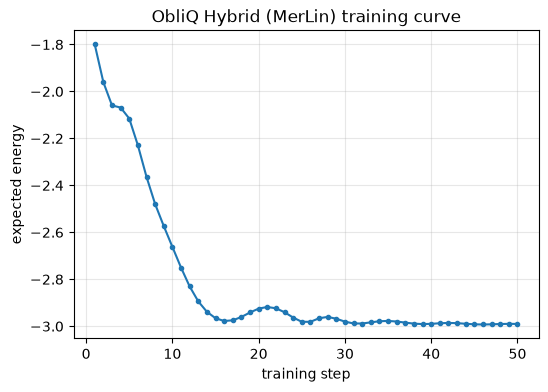

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(curve) + 1), curve, marker="o", ms=3)
plt.xlabel("training step")
plt.ylabel("expected energy")
plt.title("ObliQ Hybrid (MerLin) training curve")
plt.grid(alpha=0.3)
plt.show()

## Results: exact optimum vs. static vs. hybrid

Finally we switch the trained model to evaluation mode, decode its distribution, and line up all four numbers: the exact optimum, the static anchor, the untrained hybrid (which matches the seed), and the trained hybrid. We expect the trained hybrid to match or beat the static anchor and to approach the exact optimum — the whole point of ObliQ's design, a strong encoded starting point that only needs light variational refinement.

Each row prints its bitstring too, so the recovered vertex set can be matched against the exact one directly. A graph can hold several maximum cliques, so a bitstring that differs from the exact one while reporting the same size is equally optimal — compare the sizes first, then the bits.

In [9]:
# Call the trained model and decode; compare against the baselines.
hybrid.eval()
trained_res = distribution_to_result(
    run_distribution(hybrid, cfg)[0].tolist(), Q, 0, hybrid.output_keys
)

print(f"{'':<18}{'clique':>6}   bitstring")
print(f"{'exact optimum':<18}{best_clique:>6}   {as_bits(best_bits)}")
print(f"{'static':<18}{static_res.objective:>6.0f}   {as_bits(static_res.bitstring)}")
print(f"{'hybrid untrained':<18}{untrained_res.objective:>6.0f}   {as_bits(untrained_res.bitstring)}")
print(f"{'hybrid trained':<18}{trained_res.objective:>6.0f}   {as_bits(trained_res.bitstring)}")

                  clique   bitstring
exact optimum          3   0,0,1,1,0,0,0,1
static                 2   0,1,1,0,0,0,1,1
hybrid untrained       2   0,1,1,0,0,0,1,1
hybrid trained         3   0,1,1,0,0,0,1,0


## Using ObliQ on your own problem

`run_obliq_solver` is the whole method behind one call: it encodes the QUBO, builds the
circuit, trains the coefficients if you pass a `train` block, decodes the output and
returns the bitstring with its objective. Its keyword arguments *are* a config's
`solver_options`, so anything below can be moved into `configs/` unchanged.

To apply ObliQ to your own graph you need only a QUBO matrix: build one with
`utils.qubo.build_qubo` for Max-Cut/Max-Clique, or hand over any symmetric matrix of your
own. Nothing else in the call changes.

In [10]:
# ObliQ on a QUBO of your own: one call encodes, trains and decodes.
from models.obliq import run_obliq_solver

result = run_obliq_solver(
    Q,                                   # any symmetric QUBO matrix
    variant="obliq-hybrid",
    nsamples=5000,
    num_rep=NUM_REP,
    train={"optimizer": "adam", "max_iter": 50},
    seed=SEED,
)
print(f"bitstring = {as_bits(result.bitstring)}   clique = {result.objective:.0f}"
      f"  |  best = {best_clique}")
print(f"metadata  = {result.metadata}")

# `solver_options` in a config are exactly this function's keyword arguments, so a
# config and a notebook call are the same thing. Swapping the variant is a one-word
# change, and obliq-static needs no `train` block at all:
static_again = run_obliq_solver(Q, variant="obliq-static", nsamples=5000, num_rep=NUM_REP)
print(f"obliq-static     = {as_bits(static_again.bitstring)}"
      f"   clique = {static_again.objective:.0f}")

bitstring = 0,1,1,0,0,0,1,0   clique = 3  |  best = 3
metadata  = {'graph_mode': 0, 'candidate_count': 8, 'energy': np.float64(-3.0), 'augmented': False, 'normalized_energy': -3.0, 'variant': 'obliq-hybrid', 'nsamples': 5000, 'num_rep': 10, 'coeffs_provided': True, 'circuit_modes': 8, 'trained': True}
obliq-static     = 0,1,1,0,0,0,1,1   clique = 2


### The uniform solver interface

`models.solver.run_solver` is the single entry point the benchmark uses for *every*
solver: same arguments, bitstring out. That is what makes the comparison fair — ObliQ,
QAOA, CVaR-VQE and the annealers are all scored by the same code on the same QUBO.

In [11]:
# The harness reaches every solver through one uniform call, which returns just a
# bitstring -- so the benchmark scores ObliQ, QAOA and CVaR-VQE identically.
from models.solver import run_solver

for solver in ("obliq-static", "obliq-hybrid"):
    bits = [int(b) for b in run_solver(
        solver,
        Q,
        graph=G,
        problem_type="max-clique",
        solver_options={"nsamples": 5000, "num_rep": NUM_REP,
                        **({"train": {"optimizer": "adam", "max_iter": 50}}
                           if solver != "obliq-static" else {})},
        seed=SEED,
    )]
    print(f"{solver:13} -> {as_bits(bits)}"
          f"   clique = {-float(np.array(bits) @ Q @ np.array(bits)):.0f}")

obliq-static  -> 0,1,1,0,0,0,1,1   clique = 2
obliq-hybrid  -> 0,1,1,0,0,0,1,0   clique = 3


## Benchmarking: Q-score across problem sizes

To benchmark the paper's headline ideas we sweep over problem size $N$ and run many random instances per size, for ObliQ alongside baseline solvers (QAOA and photonic CVaR-VQE). The commands below are run from a terminal: `benchmark.py` evaluates each solver over the sweep, and `plotter.py` aggregates the saved results into the comparison figure shown next. Two quantities summarize the results:

**Beta ($\beta$)** rescales a solver's objective so that random guessing sits at $0$ and the exact optimum at $1$,
$$
\beta = \frac{C_\text{solver} - C_\text{random}}{C_\text{exact} - C_\text{random}}
$$
So $\beta = 0$ means no better than random and $\beta = 1$ means optimal. Two normalizations are available for Max-Clique: with `plotter.py -e` each instance is scored against *its own* graph (naive random search vs. the true maximum clique), which is the honest choice at these small $N$; without `-e` the Q-score standard's asymptotic constants are used instead, which deflate $\beta$ noticeably below $N \approx 10$. The figure below uses the exact form.

**Q-score** is the largest problem size $N$ whose mean $\beta$ stays above the threshold $\beta^* = 0.2$ (within the 60&nbsp;s per-instance time limit), with every smaller size clearing it as well: it stops at the first failure, so a solver whose $\beta$ dips below the line and recovers is not credited with the larger size. A higher Q-score means the solver keeps finding good solutions on larger, harder instances — it is the single number used to rank solvers.

In [12]:
# Benchmark across problem sizes with the config-driven sweep, then plot.
# Run from a terminal in this directory (shown here for reference):
#
#   python benchmark.py sweep --config configs/obliqstatic_maxclique.json
#   python benchmark.py sweep --config configs/obliqvqc_maxclique.json
#   python benchmark.py sweep --config configs/obliq_maxclique.json
#   python benchmark.py sweep --config configs/qaoa_maxclique.json
#   python benchmark.py sweep --config configs/cvarvqe_maxclique.json
#
#   python plotter.py -e -o comparison1.png \
#       -f configs/obliqstatic_maxclique.json configs/obliqvqc_maxclique.json \
#          configs/obliq_maxclique.json configs/qaoa_maxclique.json \
#          configs/cvarvqe_maxclique.json
#
# Each config already pins its sweep (sizes 2-8, 100 instances/size, seed 101200), so
# no --sizes/--instances overrides are needed. That matters: results are stored under
# a hash of the config and the plotter re-hashes the same file to find them, so
# overriding the sweep on one side only would send the plotter to a directory that
# does not exist.

The left panel plots mean $\beta$ against problem size $N$ for each solver, with the dashed line marking the $\beta^*\ = 0.2$ Q-score threshold; the Q-score in each legend entry is the largest $N$ clearing that line with every smaller size clearing it too. The right panel shows mean per-instance wall-clock time; the 60&nbsp;s Q-score limit is drawn only when it is on-scale, and here every run finishes far below it.

**This figure is from an earlier sweep** ($N = 2$ to $7$, three solvers, COBYLA training) and is kept as the measurement that was actually taken. The configs now sweep $N = 2$ to $8$ with matched hyperparameters across all six locally runnable solvers, so re-running the commands above regenerates it.

ObliQ Hybrid holds $\beta \approx 0.92$–$1.0$ across the whole range, above QAOA and well above CVaR-VQE, which falls *below* 0.8 at $N = 4$–$5$ before recovering.  ObliQ and QAOA both reach 7; the sweep does not go far enough to separate those two on that single number — the mean-$\beta$ curve is the informative comparison, and ObliQ leading it supports the results reported in the ObliQ paper.

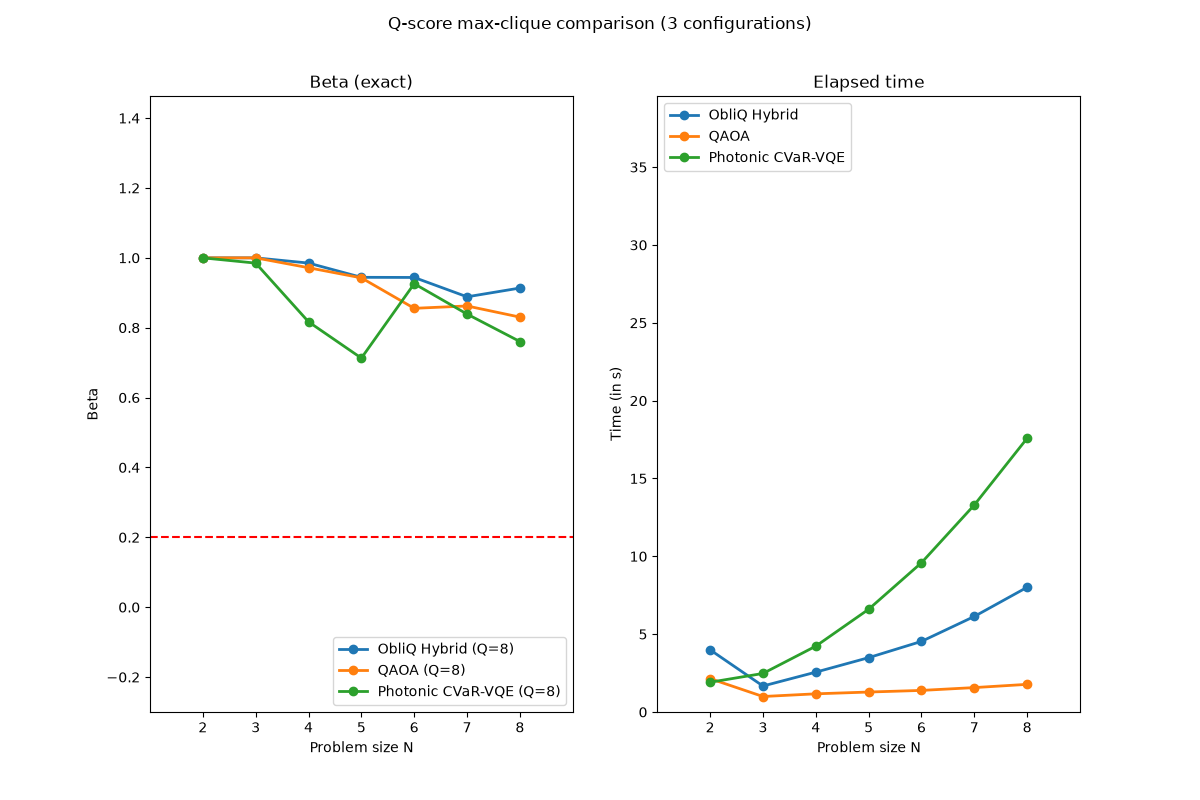

In [1]:
from IPython.display import Image

Image(filename="plots/comparison.png")